# tmp — feb25 (DEL)

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')

cfg_vae['seq_len'] = 128
cfg_vae['tbptt_steps'] = 32
cfg_vae['n_iters_inner'] = 1

# cfg_vae['fit_prior'] = False
cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 128.0
cfg_tr['epochs'] = 300

cfg_tr['optimizer'] = 'adamax'
cfg_tr['grad_clip'] = 1000

mod = IPVAE(ConfigPoisVAE(**cfg_vae))
self = tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

In [4]:
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")

vH16_t-128[§32]_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(128:0.1)_temp(0.05:0.5)_gr(1000)_(2025_02_15,08:07)

In [5]:
print(mod.cfg.sequences)

{0: range(0, 32), 1: range(32, 64), 2: range(64, 96), 3: range(96, 128)}

In [6]:
tr.train()

epoch # 300, avg loss: 167.417293: 100%|██| 300/300 [24:33:57<00:00, 294.79s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([ 49,  52,  58,  66,  75,  84,  93, 102, 111, 120, 127, 134, 141, 146,
        151, 155, 158, 160, 162, 164, 165, 167, 167, 168, 168, 169, 169, 169,
        169, 169, 169, 169, 169, 169, 169, 169, 169, 169, 169, 169, 168, 168,
        168, 168, 168, 168, 168, 168, 168, 168, 168, 168, 167, 167, 167, 167,
        167, 167, 167, 167, 167, 167, 167, 167, 167, 167, 167, 167, 167, 167,
        167, 167, 167, 167, 167, 167, 166, 166, 166, 166, 166, 166, 166, 166,
        166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166,
        166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166, 166,
        166, 166, 166, 166, 166, 166, 166, 165, 166, 166, 166, 166, 166, 166,
        166, 166], device='cuda:2', dtype=torch.int32)

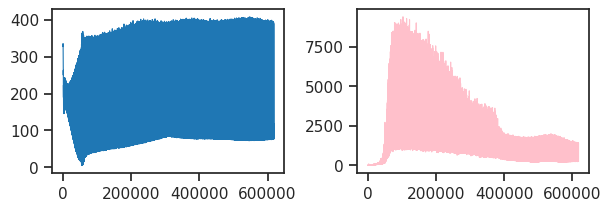

In [9]:
fig, axes = create_figure(1, 2)
axes[0].plot(list(tr.stats['loss'].values()), lw=0.8,)
axes[1].plot(list(tr.stats['grad'].values()), lw=0.8, color='pink');

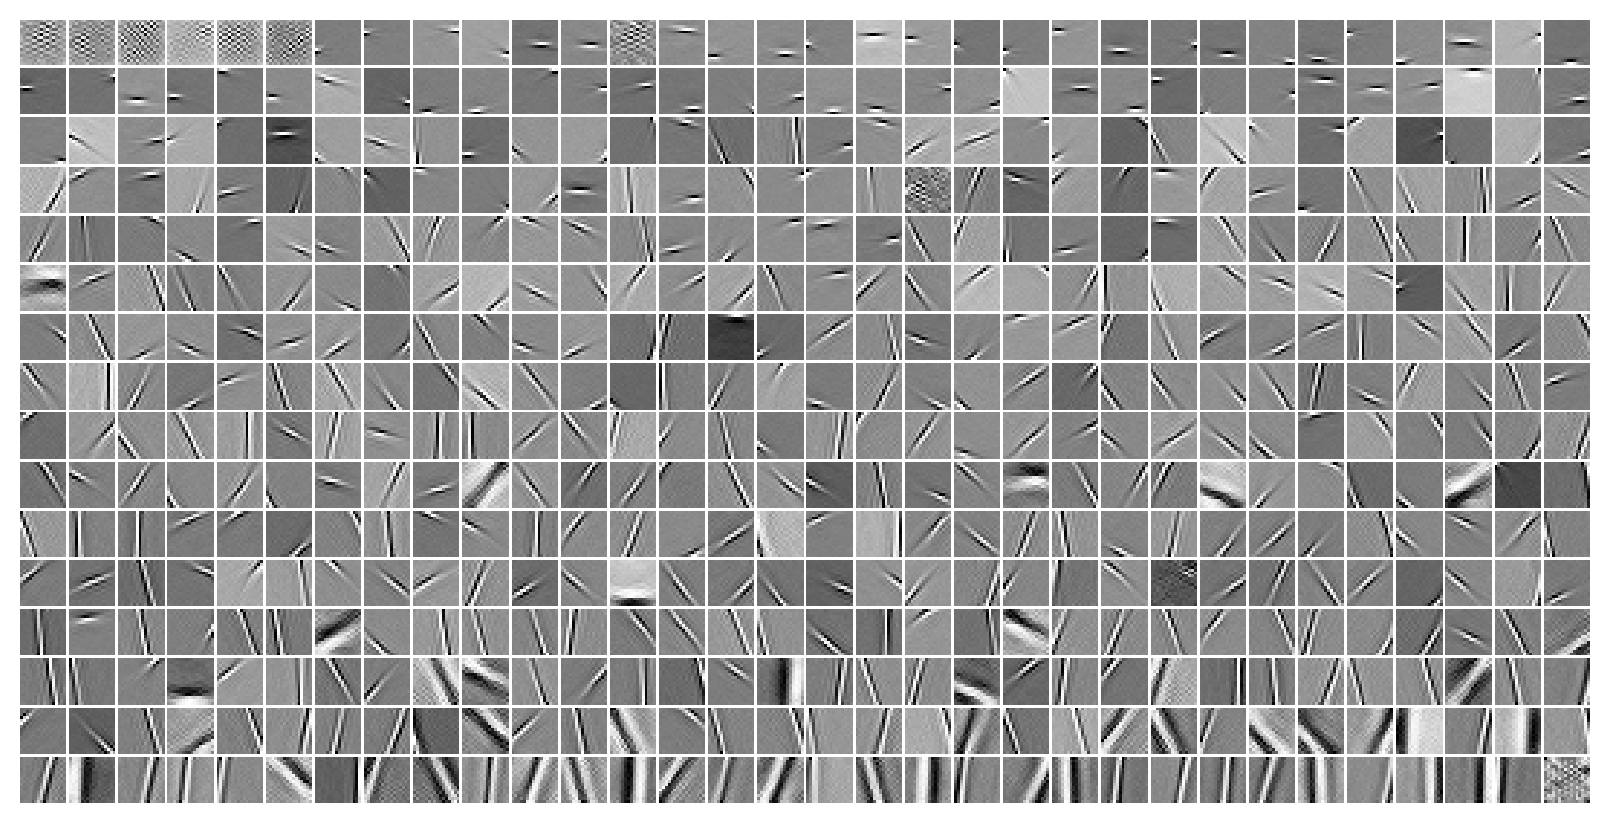

In [10]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

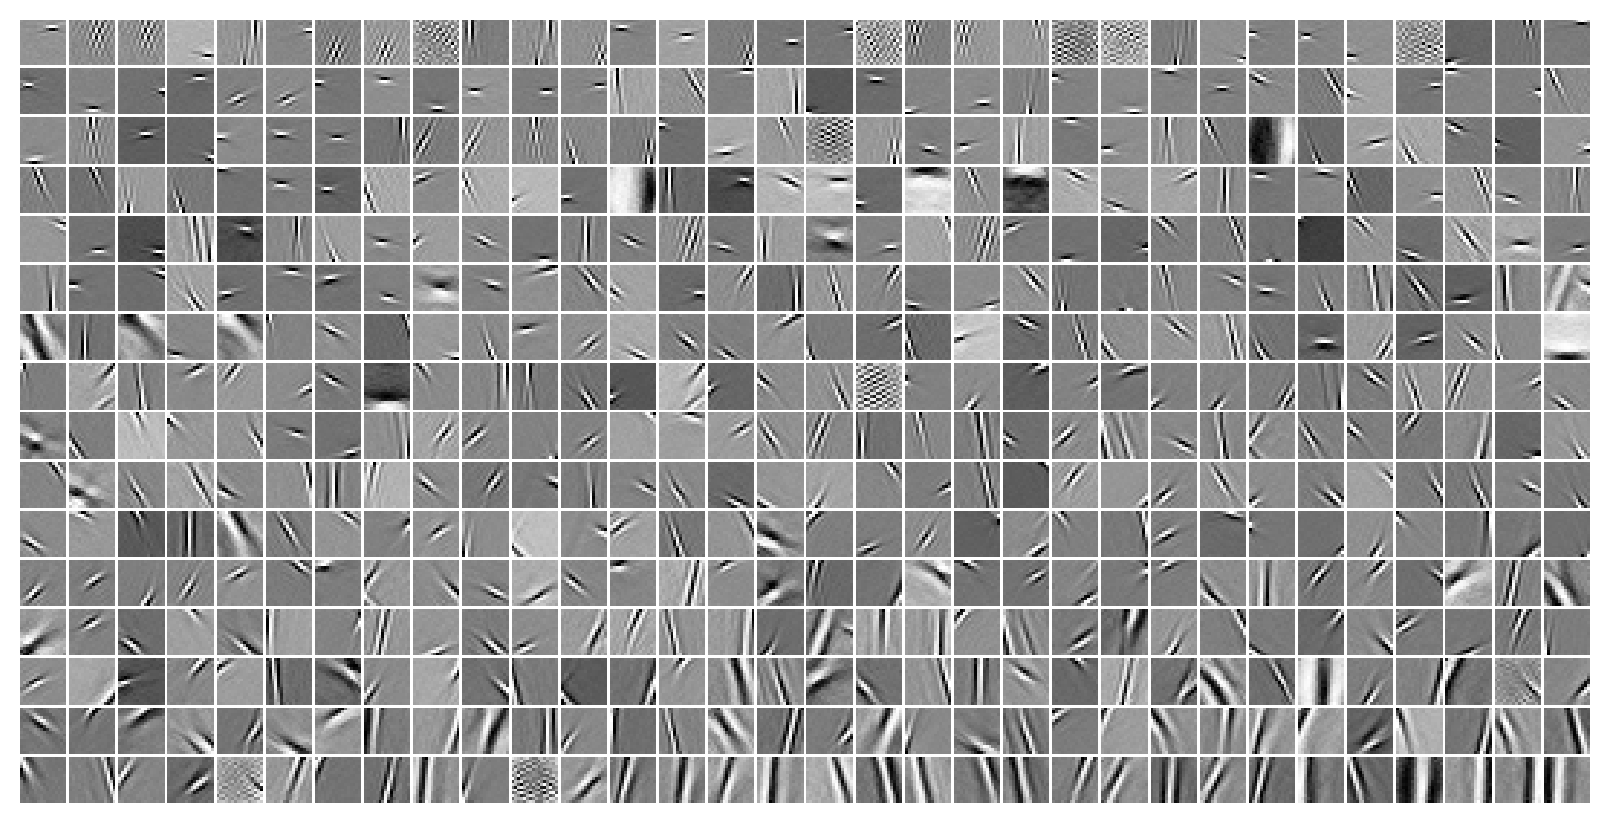

In [9]:
## Was: (16, 20.0)

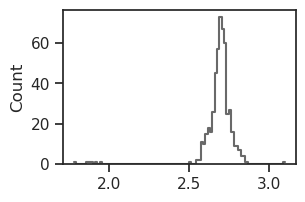

In [11]:
histplot(u0, color='dimgray');

100%|███████████████████████████████████| 2/2 [01:04<00:00, 32.43s/it]


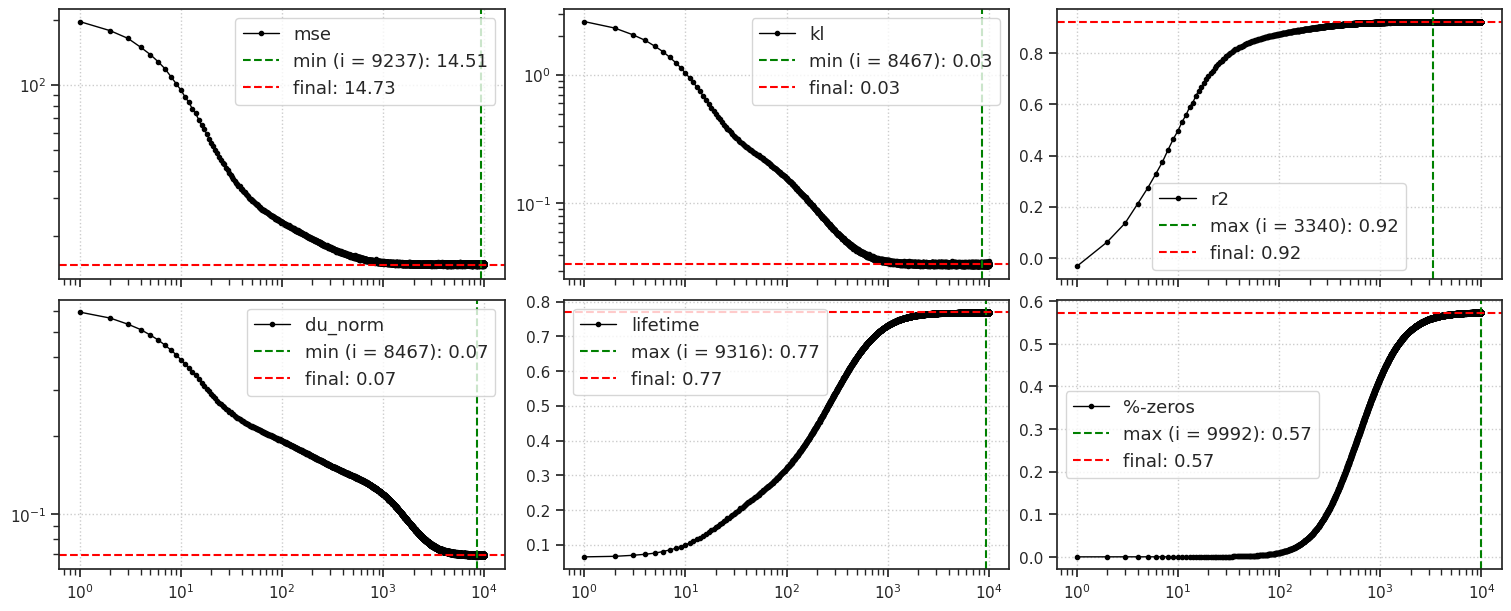

CPU times: user 1min 15s, sys: 7.2 s, total: 1min 22s
Wall time: 1min 22s


In [12]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [13]:
mod.cfg.clamp_u, mod.cfg.clamp_du

(8.0, 7.0)

In [14]:
u_min = np.asarray(tr.model.stats['u_min'])
u_max = np.asarray(tr.model.stats['u_max'])
du_min = np.asarray(tr.model.stats['du_min'])
du_max = np.asarray(tr.model.stats['du_max'])

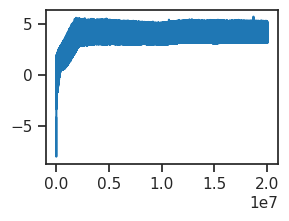

In [15]:
plt.plot(u_max)

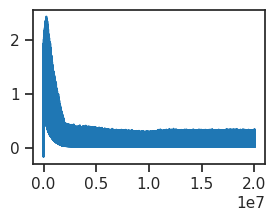

In [16]:
plt.plot(du_max)

In [17]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

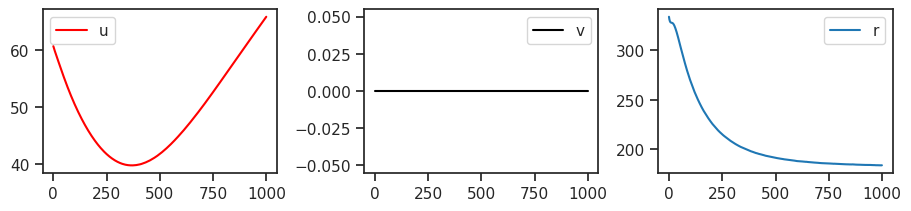

In [18]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()